<h3> Function Transformer <h3>

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('/home/varsha/PracticePython/100DaysOfMl/ML6_Pipelines/Titanic_Dataset.csv', usecols=['Age', 'Fare','Survived'])

In [4]:
df.head(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipykernel_17083/1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [7]:
df.head(4)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000


In [8]:
X = df.iloc[:, 1:3]
Y = df.iloc[:, 0]

In [9]:
X

,Age,Fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [10]:
Y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=0)

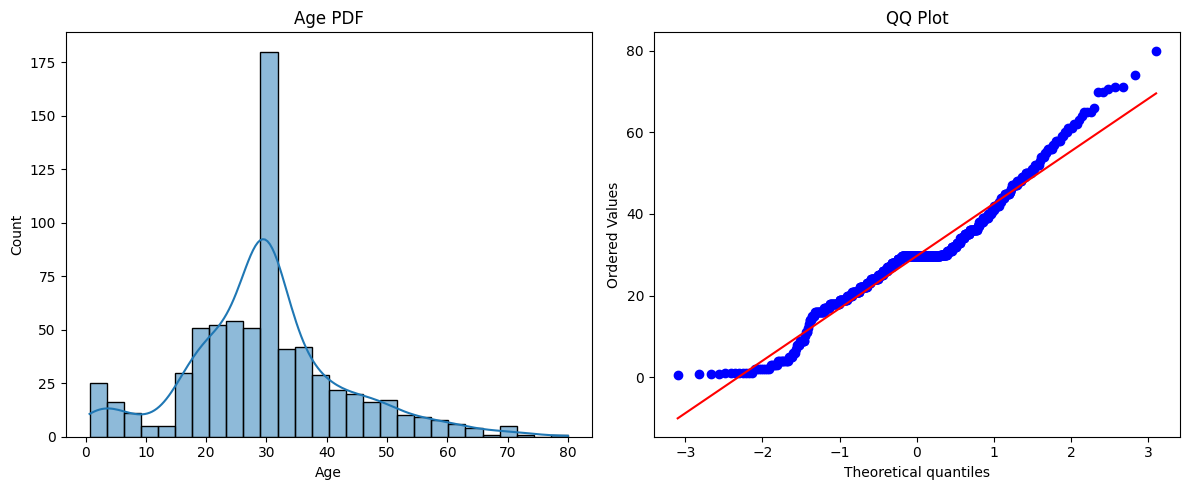

In [12]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

# QQ Plot
plt.subplot(1,2,2)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title("QQ Plot")

plt.tight_layout()
plt.show()



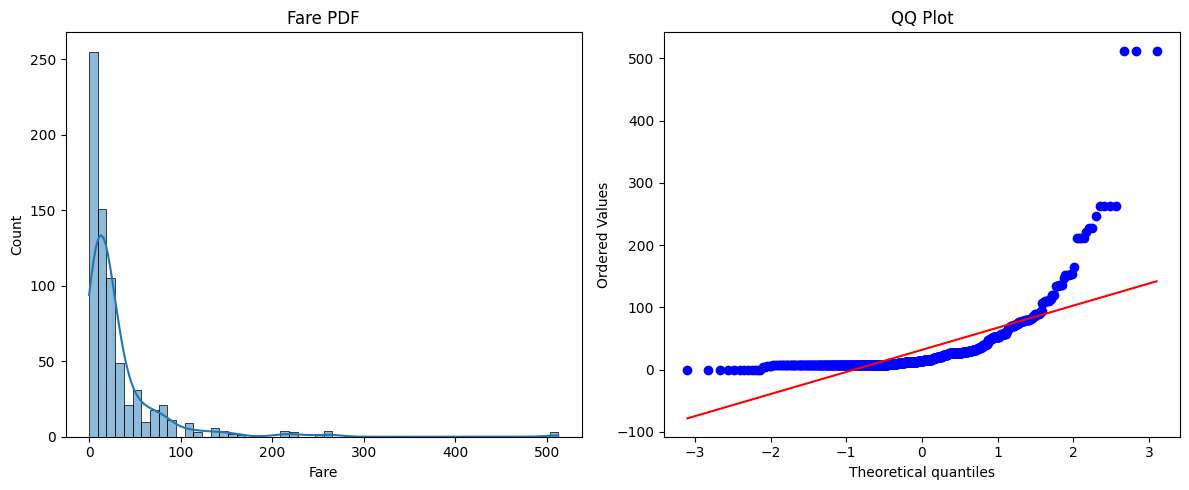

In [73]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

# QQ Plot
plt.subplot(1,2,2)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title("QQ Plot")

plt.tight_layout()
plt.show()



In [74]:
clf_obj = LogisticRegression()
clf2_obj = DecisionTreeClassifier()

In [75]:
clf_obj.fit(X_train,y_train)
clf2_obj.fit(X_train, y_train)

y_pred1 = clf_obj.predict(X_test)
y_pred2 = clf2_obj.predict(X_test)

In [76]:
accuracy1 = accuracy_score(y_test,y_pred1)
accuracy2 = accuracy_score(y_test,y_pred2)

In [78]:
trf = FunctionTransformer(func = np.log1p)

In [79]:
X_train_transformed = trf.fit(X_train)
X_test_transformed = trf.fit(X_test)

In [82]:
clf1 = DecisionTreeClassifier()
clf2 = LogisticRegression()

In [ ]:
clf1.fit()